In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("spotify.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [12]:
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [14]:
# 1 Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do
# the needful?
df.isnull().sum()

Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64

In [16]:
#there is no null null values present in dataset

In [35]:
df.drop_duplicates(inplace = True)

In [37]:
df.duplicated().sum()

0

In [39]:
#Duplicate values were identified and removed, ensuring the dataset now contains only unique records.

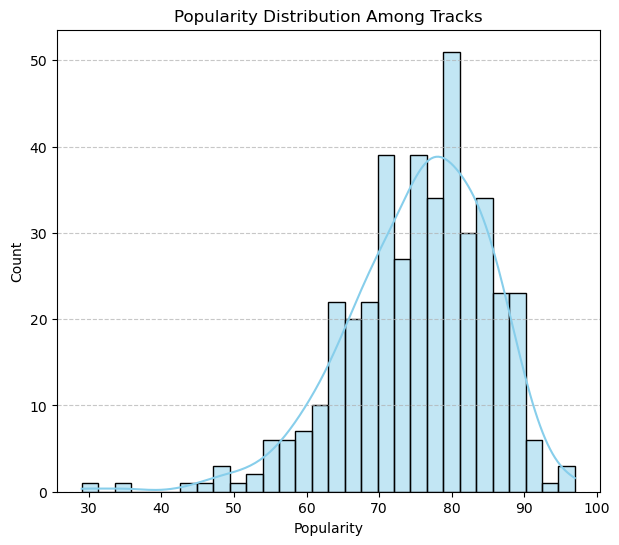

In [99]:
# 2 What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.
plt.figure(figsize = (7,6))
sns.histplot(df['Popularity'],bins=30,kde = True,color = 'skyblue')
plt.title("Popularity Distribution Among Tracks")
plt.grid(axis = 'y',linestyle = '--',alpha=0.7)
plt.show()

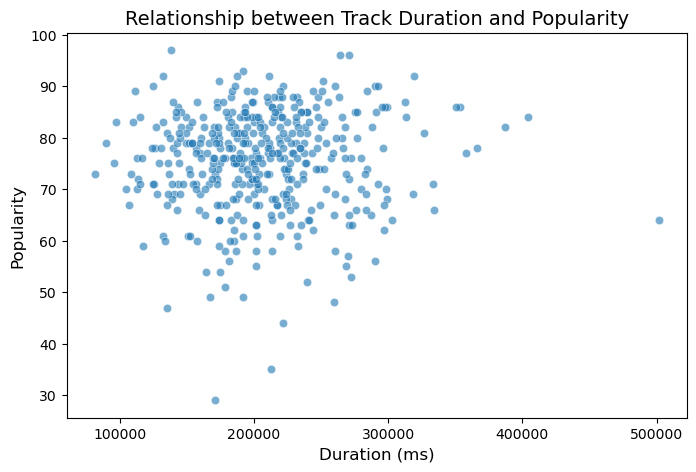

In [119]:
# 3 Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot?
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration (ms)', y='Popularity', data=df, alpha=0.6)

plt.title("Relationship between Track Duration and Popularity", fontsize=14)
plt.xlabel("Duration (ms)", fontsize=12)
plt.ylabel("Popularity", fontsize=12)
plt.show()


In [ ]:
# The points are scattered all over without forming a strong upward or downward slope.a
# This suggests weak or no strong correlation between track duration and popularity.
# The scatter plot indicates no strong relationship between track duration and popularity. Most popular tracks tend to have durations 
# between 2.5 to 4 minutes, while extremely long tracks are relatively less popular. The correlation coefficient further confirms 
# a weak association.

In [127]:
df[['Duration (ms)','Popularity']].corr()

,Duration (ms),Popularity
Duration (ms),1.000000,0.038992
Popularity,0.038992,1.000000


In [129]:
# The correlation coefficient between track duration and popularity is 0.04, indicating almost no linear relationship. 
# This confirms that track length does not significantly influence popularity.

In [145]:
# 4 Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.
df['Artist'].value_counts()

Artist
Drake             17
Eminem            11
Flo Rida          10
Ludacris          10
Timbaland         10
                  ..
Arizona Zervas     1
Fivio Foreign      1
Pressa             1
David Guetta       1
Diddy              1
Name: count, Length: 115, dtype: int64

In [ ]:
#Drake is the artist who has highest number of tracks in the dataset with 17 tracks.

In [151]:
#since number of artist are 115 , its not good visualisation using countplot with 115 artist, So i will prefer to visualise top 10 artist
# with respect to their Tracks
top_artist = df['Artist'].value_counts().head(10)
top_artist

Artist
Drake           17
Eminem          11
Flo Rida        10
Ludacris        10
Timbaland       10
¥$              10
21 Savage       10
JAY-Z           10
Lil Nas X       10
Travis Scott     9
Name: count, dtype: int64

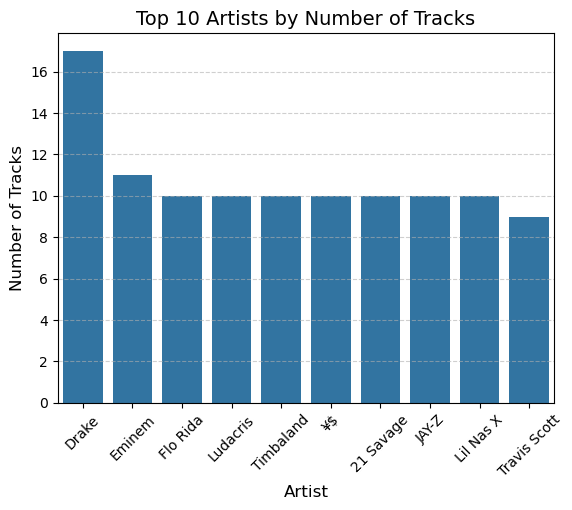

In [163]:
sns.countplot(x='Artist', data=df,order=df['Artist'].value_counts().index[:10])
plt.title("Top 10 Artists by Number of Tracks", fontsize=14)
plt.xlabel("Artist", fontsize=12)
plt.ylabel("Number of Tracks", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis = 'y',linestyle='--',alpha =0.6)
plt.show()

In [173]:
# 5 What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each?
df[['Artist','Popularity','Track Name']].sort_values(by = 'Popularity',ascending = True).head(5)

,Artist,Popularity,Track Name
207,Pressa,29,Attachments (feat. Coi Leray)
231,Justin Bieber,35,Intentions
413,French Montana,44,Splash Brothers
225,Lil Baby,47,On Me - Remix
407,Wyclef Jean,48,911 (feat. Mary J. Blige)


In [181]:
#6 Among the top 5 most popular artists, which artist has the highest popularity on average? 
#Calculate and display the average popularity for each artist?
df.groupby('Artist')['Popularity'].mean().sort_values(ascending = False).head(5).round(2)

Artist
cassö           92.00
Trueno          89.00
David Guetta    87.00
Travis Scott    86.56
¥$              85.10
Name: Popularity, dtype: float64

In [183]:
#So, the artist with the highest average popularity is cassö (92.00).

In [197]:
# 7 For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist?
df[['Artist','Popularity','Track Name']].sort_values(by='Popularity',ascending = False).reset_index(drop=True).head(5)

,Artist,Popularity,Track Name
0,Jack Harlow,97,Lovin On Me
1,21 Savage,96,redrum
2,¥$,96,CARNIVAL
3,Travis Scott,93,FE!N (feat. Playboi Carti)
4,cassö,92,Prada


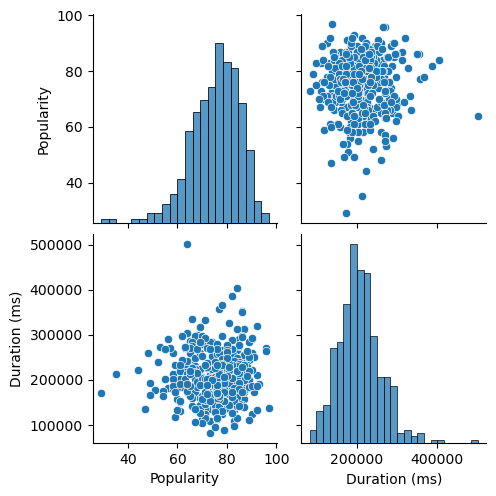

In [199]:
# 8 Visualize relationships between multiple numerical variables simultaneously using a pair plot?
numerical_cols = ['Popularity', 'Duration (ms)']
sns.pairplot(df[numerical_cols])
plt.show()

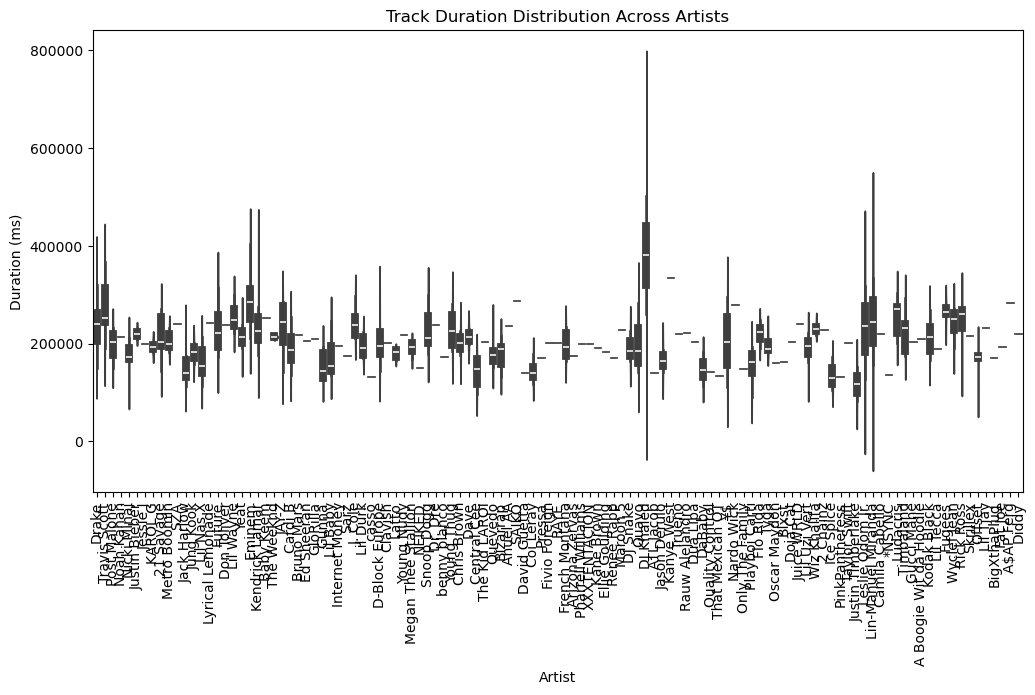

In [205]:
# 9 Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot
plt.figure(figsize=(12,6))
sns.violinplot(x='Artist', y='Duration (ms)', data=df)
plt.xticks(rotation=90)
plt.title("Track Duration Distribution Across Artists")
plt.show()


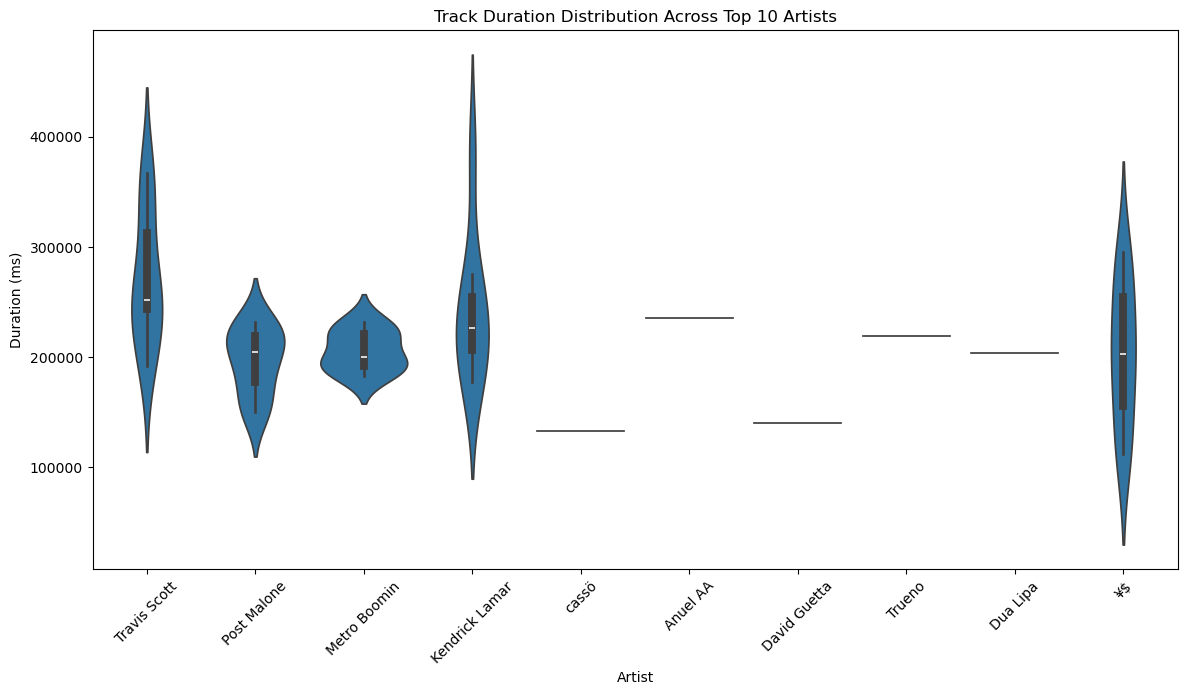

In [209]:
#we have many artists, it’s better to focus on the top 5 or top 10 most popular artists for clarity

top_artists = df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(10).index
top_artists_df = df[df['Artist'].isin(top_artists)]
plt.figure(figsize=(14,7))
sns.violinplot(x='Artist', y='Duration (ms)', data=top_artists_df)
plt.xticks(rotation=45)  # Rotate labels for readability
plt.title("Track Duration Distribution Across Top 10 Artists")
plt.ylabel("Duration (ms)")
plt.xlabel("Artist")
plt.show()


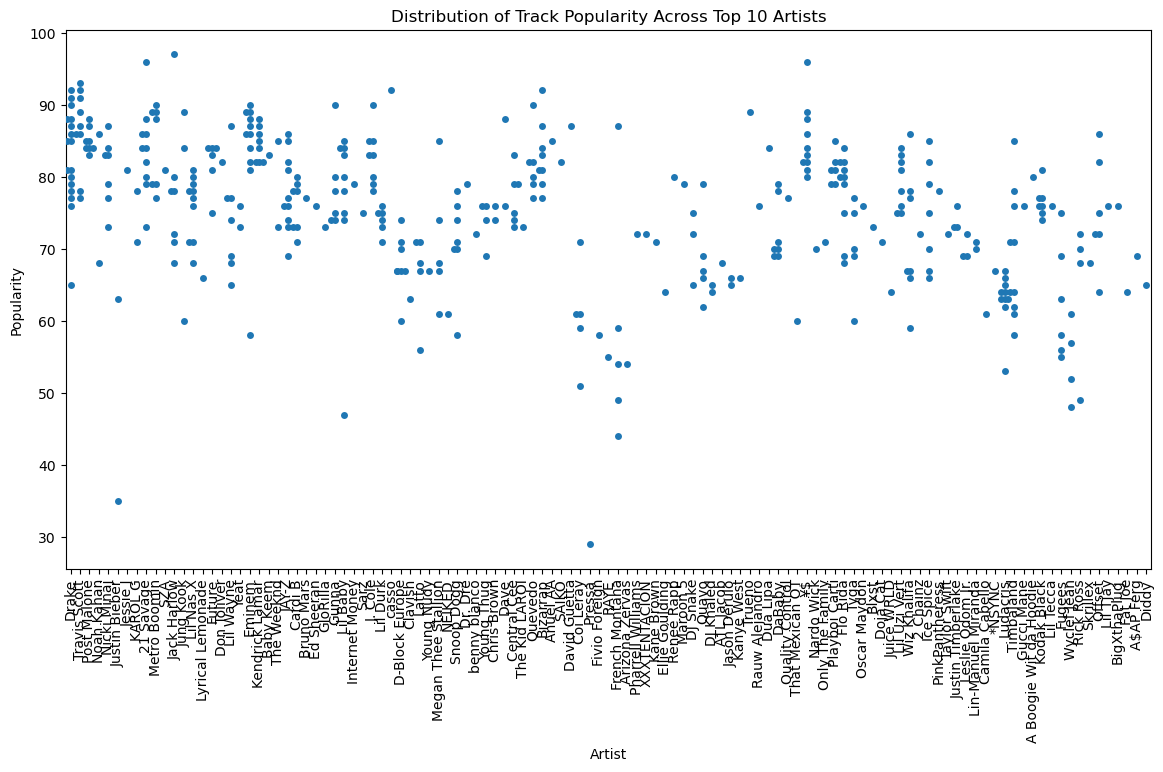

In [218]:
# 10 How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a
# violin plot?

plt.figure(figsize=(14,7))
sns.swarmplot(x='Artist', y='Popularity', data=df, size=5)
plt.xticks(rotation=90)
plt.title("Distribution of Track Popularity Across Top 10 Artists")
plt.ylabel("Popularity")
plt.xlabel("Artist")
plt.show()
